In [81]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

torch.set_default_dtype(torch.float64)

In [82]:
# Physical Parameters
E = 2e11
NU = 0.3
R = 1
h = 0.01
P = 1e7

Dm = (E*h)/(1-NU**2)
Db = (E*h**3)/(12*(1-NU**2))

# Non-dimensionalization
w0 = h
u0 = w0**2 / R

# BCs: Choose from {'rigidly clamped', 'loosely clamped',
# 'rigidly simply supported', 'loosely simply supported'}
condition = 'rigidly clamped'

# Hyperparameters
epochs_Adam = 1000
epochs_LBFGS = 500
lr = 0.001
num_interior = 50
num_boundary = 100
lambda_bc = 10

# Some arrays
previous_loss = float('inf')
loss_history = []

In [83]:
# 1. Neural Network Architecture
class EnergyPINN(nn.Module):
    def __init__(self, input_size, output_size, hidden_size):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, output_size)
        )
        
    def forward(self, r_norm):
        output = self.network(r_norm)
        u_norm = output[:, 0:1]
        w_norm = output[:, 1:2]

        # 1. Vertical Deflection (w) Constraints
        # for perfect symmetric circular plate, the slope
        # at the center is 0 -> dw/dr(0) = 0
        if 'clamped' in condition:
            # CLAMPED: w(1) = 0, dw/dr(1) = 0, dw/dr(0) = 0
            w = w_norm * (1.0 - r_norm**2)**2
        else:
            # SIMPLY SUPPORTED: w(1) = 0, dw/dr(0) = 0
            w = w_norm * (1.0 - r_norm**2)
            
        # 2. Radial Displacement (u) Constraints
        if 'rigidly' in condition:
            # RIGIDLY: u(0) = 0, u(1) = 0
            u = u_norm * r_norm * (1.0 - r_norm)
        else:
            # LOOSELY: u(0) = 0
            u = u_norm * r_norm

        return u*u0 , w*w0

In [84]:
def grad(f, v):
    return torch.autograd.grad(f, v, grad_outputs=torch.ones_like(f), create_graph=True)[0]


In [85]:
# 2. Potential Energy Loss Function
def nonlinear_circular_plate(model, r):
    # Enable gradient tracking
    r.requires_grad_(True)
    
    # Forward pass
    u, w = model(r / R)
    
    # Curvatures
    u_r = grad(u, r)
    w_r = grad(w, r)
    w_rr = grad(w_r, r)

    # Nonlinear Strains (von Karman)
    er = u_r + 0.5 * (w_r)**2
    et = u / (r + 1e-6) # prevents r = 0 causes NaN

    # Bending Strains
    kr = -w_rr
    kt = -(1/(r+1e-6)) * w_r

    # Strain Energy Density
    U_mem = 0.5 * Dm * (er**2 + et**2 + 2*NU*er*et)
    U_ben = 0.5 * Db * (kr**2 + kt**2 + 2*NU*kr*kt)
    U_int = torch.mean((U_mem + U_ben) * (r+1e-6)) *2*np.pi*R
    
    # External Work
    r_zero = torch.tensor([[0.0]], dtype=torch.float64, requires_grad=True)
    _, w_center = model(r_zero)
    W_ext = -P * w_center

    # Total energy
    # Integrating over the domain 2*pi*r
    Pi = U_int - W_ext
    Pi0 = P * h

    return Pi/Pi0

In [86]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EnergyPINN(1, 2, 64).to(device)

# Training Loop
print("Starting training...")

# Generate Points
r_col = torch.linspace(0, R, 2000, device=device).unsqueeze(1)

# --- PHASE 1: ADAM OPTIMIZER ---
optimizer_adam = optim.Adam(model.parameters(), lr=2e-3)
print("Phase 1: Adam Optimizer (Finding the neighborhood)")
for epoch in range(epochs_Adam+1):
    optimizer_adam.zero_grad()

    # Physics loss (Energy minimization)
    total_loss = nonlinear_circular_plate(model, r_col)

    total_loss.backward()
    optimizer_adam.step()
    
    current_loss = total_loss.item()
    loss_history.append(current_loss)

    if epoch % 500 == 0:
        print(f"Epoch {epoch} | Energy: {current_loss}")
    
    # Convergence Check
    if epoch > 0:
        relative_error = abs(previous_loss - current_loss) / abs(current_loss + 1e-15)
        if relative_error < 1e-20:
            print(f"Convergent at epoch {epoch}. Relative error: {relative_error}")
            break
    
    previous_loss = current_loss    

# --- PHASE 2: L-BFGS OPTIMIZER ---
print("\nPhase 2: L-BFGS Optimizer (High-precision polishing)")
# L-BFGS requires a static set of points during its line search closure
r_static = torch.linspace(0, R, 4000, device=device).unsqueeze(1)

optimizer_lbfgs = optim.LBFGS(model.parameters(), 
                                max_iter=epochs_LBFGS,
                                tolerance_grad=1e-9, 
                                tolerance_change=1e-11, 
                                history_size=100,
                                line_search_fn="strong_wolfe")

def closure():
    optimizer_lbfgs.zero_grad()
    loss = nonlinear_circular_plate(model, r_static)
    loss.backward()
    loss_history.append(loss.item())
    return loss
    
optimizer_lbfgs.step(closure)

# Print final loss after L-BFGS
final_loss = nonlinear_circular_plate(model, r_static)
print(f"  Final L-BFGS Energy Loss: {final_loss.item():.6e}\n")

Starting training...
Phase 1: Adam Optimizer (Finding the neighborhood)
Epoch 0 | Energy: -0.16186593200043006
Epoch 500 | Energy: -11.231711500758763
Epoch 1000 | Energy: -11.55829405327583

Phase 2: L-BFGS Optimizer (High-precision polishing)
  Final L-BFGS Energy Loss: -1.179269e+01



In [87]:
def solve_timoshenko_exact(A, B):
    """
    A*(w0/h)^3 + (w0/h) = B*(P * R^2) / (E * h^4)
    """
    RHS = B * (P * R**2) / (E * h**4)
    coeffs = [A, 0, 1.0, -RHS]
    # Find all roots
    roots = np.roots(coeffs)
    # Extract the physical (purely real) root
    real_root = roots[np.isreal(roots)].real[0]
    return real_root * h

In [88]:
device = next(model.parameters()).device
model.eval() # Set to evaluation mode

r_test = torch.linspace(0, 1.0, 100).view(-1, 1)
u_pred, w_pred = model(r_test)

w_pred = (w_pred).detach().numpy()
u_pred = (u_pred).detach().numpy()
r_plot = (r_test).numpy()

w_max = abs(w_pred[0][0])

# Timoshenko's approximate solution: (w0/h) + A*(w0/h)^3 = B*(q/E)*(R/h)^4
# nu = 0.3:
table_coeffs = {
    'rigidly clamped': {'A': 0.443, 'B': 0.217},
    'loosely clamped': {'A': 0.200, 'B': 0.217},
    'rigidly simply supported': {'A': 1.430, 'B': 0.552},
    'loosely simply supported': {'A': 0.272, 'B': 0.552}
}

A_coeff = table_coeffs[condition]['A']
B_coeff = table_coeffs[condition]['B']

w_exact = solve_timoshenko_exact(A_coeff, B_coeff)
error_w0 = abs(w_max - w_exact) / w_exact * 100

print(f"{'Numerical w:':<20} {w_max:.4e}")
print(f"{'Analytical w:':<20} {w_exact:.4e}")
print(f"{'Ratio w_max/h:':<20} {(w_max/h):.4f}")
print(f"{'Error:':<20} {error_w0:.4f}%")

Numerical w:         1.5991e-01
Analytical w:        1.3424e-01
Ratio w_max/h:       15.9912
Error:               19.1267%


The error is proportional to the ratio $w_{max}/h$, i.e., larger load $q$ or $P$ -> larger deflection "w" -> larger error.
- Timoshenko's Equation is an approximation, not exact solution.

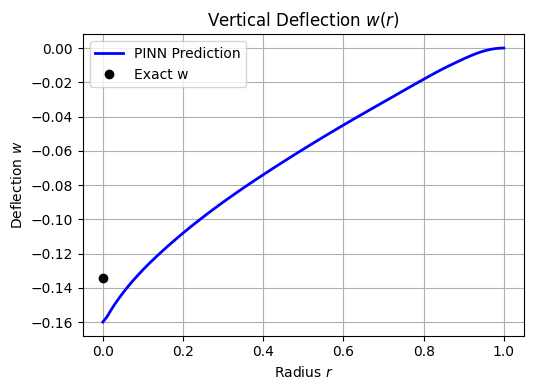

In [89]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(r_plot, w_pred, label='PINN Prediction', color='blue', linewidth=2)
plt.plot(0.0, -w_exact, 'ko', label='Exact w')
plt.title('Vertical Deflection $w(r)$')
plt.xlabel('Radius $r$')
plt.ylabel('Deflection $w$')
plt.grid(True)
plt.legend()

# plt.subplot(1, 2, 2)
# plt.plot(r_plot, u_pred, label='PINN Prediction', color='red', linewidth=2)
# plt.title('Radial Displacement $u(r)$')
# plt.xlabel('Radius $r$')
# plt.ylabel('Displacement $u$')
# plt.grid(True)
# plt.legend()

plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


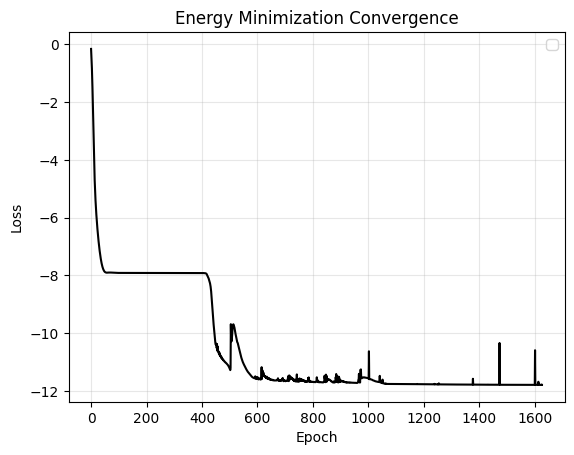

In [90]:
plt.plot(loss_history, color='black')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Energy Minimization Convergence')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()